# 04 — Leakage-safe models

**Input:** `data/analysis_panel_wages.csv`  
**Function:** compare linear and gradient-boosted models on sponsor-disjoint holdouts,
test forward transfer to FY2022, explain predictions, and isolate the contribution of
DOL wage features  
**Outputs:** `output/figures/06`–`09`, `13`–`14`; model, split, coefficient, and feature-
importance tables in `output/tables/`, plus `lgbm_sensitivity.csv`,
`model_metrics_seeds.csv`, and `robustness.csv`

The design answers three questions: how well employer characteristics predict outcomes
for entirely unseen sponsors, whether patterns learned before FY2022 transfer into that
year, and whether DOL wage information improves prediction on an identical matched sample.

In [1]:
import sys
from pathlib import Path

# Locate the repository root by walking up until code/src is found, then put the
# code directory on the path. No absolute paths, so this runs from any checkout.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "code" / "src").is_dir())
sys.path.insert(0, str(_root / "code"))

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

from src import (DATA, TABLES, MODEL_YEARS, finish, save,
                 C1, C2, SEQ, INK, INK2, MUTED)
from src.diagnostics import describe_frame, merge_report

warnings.filterwarnings("ignore")
SEED = 45

## Functions and feature definitions

The rate models are weighted by the number of initial petitions because a proportion
based on 100 adjudications is measured more precisely than a proportion based on one.
WLS confidence intervals are clustered by canonical employer to allow correlation across
years. The any-denial classifiers remain employer-year models and are evaluated with AUC.

In [2]:
NUMERIC = ["log_initial", "continuing_share", "log_prev_initial",
           "prev_denial_rate", "prior_active_years", "is_repeat_sponsor"]
CATEG = ["sector", "state_grp", "fy_cat"]

WAGE_NUM = ["wage_ratio_med", "log_wage_annual", "share_low_level",
            "share_agent", "share_dependent", "log_lca_filings"]
WAGE_CAT = ["soc2_modal"]

PRETTY = {
    "log_initial": "log(1 + initial petitions)",
    "continuing_share": "Continuing (renewal) share",
    "log_prev_initial": "log(1 + prior-yr initial petitions)",
    "prev_denial_rate": "Prior-year denial rate",
    "prior_active_years": "Prior active sponsor-years",
    "is_repeat_sponsor": "Sponsored in prior year",
    "wage_ratio_med": "Offered / prevailing wage",
    "log_wage_annual": "log(median offered wage)",
    "share_low_level": "Position share at PW level I or II",
    "share_agent": "Share filed via agent or attorney",
    "share_dependent": "Share at H-1B dependent employer",
    "log_lca_filings": "log(1 + LCA filings)",
}

SHAP_NAMES = dict(PRETTY)
SHAP_NAMES.update({"fy_cat": "Fiscal year", "sector": "Industry sector",
                   "state_grp": "State", "soc2_modal": "Modal SOC group"})


def design_matrices(frame, numeric, categorical):
    '''Create one-hot linear and native-categorical LightGBM designs.'''
    X_lin = pd.get_dummies(frame[numeric + categorical],
                           columns=categorical, drop_first=True).astype(float)
    X_gbm = frame[numeric + categorical].copy()
    for c in categorical:
        X_gbm[c] = X_gbm[c].astype("category")
    return X_lin, X_gbm


def group_partitions(frame, seed=SEED):
    '''Create 56/14/30 train/validation/test rows with disjoint employer keys.'''
    outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    dev, test = next(outer.split(frame, groups=frame.key))
    inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed + 1)
    train_rel, val_rel = next(inner.split(frame.iloc[dev], groups=frame.iloc[dev].key))
    train, val = dev[train_rel], dev[val_rel]
    return np.asarray(train), np.asarray(val), np.asarray(test)


def split_diagnostic(frame, train, val, test, label):
    '''Verify key separation and report fiscal-year balance.'''
    parts = {"train": train, "validation": val, "test": test}
    keys = {name: set(frame.iloc[idx].key) for name, idx in parts.items()}
    assert not (keys["train"] & keys["validation"])
    assert not (keys["train"] & keys["test"])
    assert not (keys["validation"] & keys["test"])
    out = []
    print(label)
    for name, idx in parts.items():
        print(f"  {name:10s} rows={len(idx):,} employers={frame.iloc[idx].key.nunique():,}")
        shares = frame.iloc[idx].fy.value_counts(normalize=True).sort_index()
        for fy, share in shares.items():
            out.append({"sample": label, "partition": name, "fy": fy,
                        "rows": len(idx), "employers": frame.iloc[idx].key.nunique(),
                        "year_share": share})
    print("  employer overlap across partitions: 0")
    return pd.DataFrame(out)


# Every fixed LightGBM setting lives here. The tree count is the only value chosen
# on validation data (early stopping with EARLY_STOP rounds of patience).
LGB_PARAMS = dict(n_estimators=1000, learning_rate=0.04, num_leaves=48,
                  min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, verbose=-1)
EARLY_STOP = 60

# Logistic baseline: no penalty (C=inf), lbfgs, unscaled one-hot design. Recorded
# here so the comparison with the LightGBM classifier is not against a ridge fit.
LOGIT_KW = dict(C=np.inf, max_iter=5000)


def lgb_regressor(**kw):
    return lgb.LGBMRegressor(**{**LGB_PARAMS, **kw})


def lgb_classifier(**kw):
    return lgb.LGBMClassifier(**{**LGB_PARAMS, **kw})


def fit_wls(X, y, weights, groups, idx):
    '''Petition-weighted rate model with employer-clustered covariance.'''
    exog = sm.add_constant(X.iloc[idx], has_constant="add")
    return sm.WLS(y[idx], exog, weights=weights[idx]).fit(
        cov_type="cluster", cov_kwds={"groups": groups[idx]})


def tune_refit_regressor(X, y, weights, train, val, dev, **kw):
    '''Choose tree count on validation data, then refit on development rows.'''
    tuned = lgb_regressor(**kw)
    tuned.fit(X.iloc[train], y[train], sample_weight=weights[train],
              eval_set=[(X.iloc[val], y[val])], eval_sample_weight=[weights[val]],
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    best = int(tuned.best_iteration_ or tuned.n_estimators)
    final = lgb_regressor(n_estimators=best, **kw)
    final.fit(X.iloc[dev], y[dev], sample_weight=weights[dev])
    return final, best


def tune_refit_classifier(X, y, train, val, dev, **kw):
    '''Tune only on validation data; never expose the test labels to training.
    Early stopping here is unweighted (binary log loss on validation rows).'''
    tuned = lgb_classifier(**kw)
    tuned.fit(X.iloc[train], y[train], eval_set=[(X.iloc[val], y[val])],
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    best = int(tuned.best_iteration_ or tuned.n_estimators)
    final = lgb_classifier(n_estimators=best, **kw)
    final.fit(X.iloc[dev], y[dev])
    return final, best


def fit_fraclogit(X, y, weights, groups, idx):
    '''Fractional logit: GLM Binomial on the [0,1] rate with petition weights
    and employer-clustered covariance. Predictions stay inside the unit interval.'''
    keep = [c for c in X.columns if X.iloc[idx][c].nunique() > 1]  # drop constant dummies
    exog = sm.add_constant(X.iloc[idx][keep], has_constant="add")
    model = sm.GLM(y[idx], exog, family=sm.families.Binomial(),
                   var_weights=weights[idx])
    return model.fit(cov_type="cluster", cov_kwds={"groups": groups[idx]})


def predict_glm(res, X, idx):
    '''Predict from a fitted GLM using only the columns it was fitted on.'''
    cols = [c for c in res.model.exog_names if c != "const"]
    return res.predict(sm.add_constant(X.iloc[idx][cols], has_constant="add"))


def fit_pair(frame, y_rate, y_any, w, g, train, val, test, dev,
             numeric, categorical, label, verbose=True):
    '''Fit four models plus a fractional logit on one sample and one fixed set of
    partitions. Missing numeric features are imputed with the median of the
    training rows of this partition, so no validation or test row informs it.'''
    Xl, Xg = design_matrices(frame, numeric, categorical)
    for c in numeric:
        if Xl[c].isna().any():
            med = Xl[c].iloc[train].median()
            Xl[c] = Xl[c].fillna(med)
            Xg[c] = Xg[c].fillna(med)
    model_wls = fit_wls(Xl, y_rate, w, g, dev)
    pred_wls = model_wls.predict(sm.add_constant(Xl.iloc[test], has_constant="add"))
    r2_linear = r2_score(y_rate[test], pred_wls, sample_weight=w[test])

    model_gbm, trees_reg = tune_refit_regressor(Xg, y_rate, w, train, val, dev)
    r2_tree = r2_score(y_rate[test], model_gbm.predict(Xg.iloc[test]),
                       sample_weight=w[test])

    model_logit = LogisticRegression(**LOGIT_KW)
    model_logit.fit(Xl.iloc[dev], y_any[dev])
    auc_linear = roc_auc_score(
        y_any[test], model_logit.predict_proba(Xl.iloc[test])[:, 1])

    model_clf, trees_clf = tune_refit_classifier(Xg, y_any, train, val, dev)
    auc_tree = roc_auc_score(y_any[test], model_clf.predict_proba(Xg.iloc[test])[:, 1])

    model_frac = fit_fraclogit(Xl, y_rate, w, g, dev)
    r2_frac = r2_score(y_rate[test], predict_glm(model_frac, Xl, test),
                       sample_weight=w[test])

    if verbose:
        print(f"{label:22s} WLS R2={r2_linear:.4f}; LGBM R2={r2_tree:.4f}; "
              f"Logit AUC={auc_linear:.4f}; LGBM AUC={auc_tree:.4f}; "
              f"frac-logit R2={r2_frac:.4f}")
    return dict(label=label, r2_wls=r2_linear, r2_gbm=r2_tree,
                auc_logit=auc_linear, auc_gbm=auc_tree, r2_frac=r2_frac,
                wls=model_wls, gbm=model_gbm, frac=model_frac, X_lin=Xl, X_gbm=Xg,
                trees_reg=trees_reg, trees_clf=trees_clf)


def seed_metrics(frame, y_rate, y_any, w, g, numeric, categorical, label, seeds):
    '''Repeat the whole split-tune-refit-score pipeline over several seeds.'''
    rows = []
    for seed in seeds:
        tr_s, va_s, te_s = group_partitions(frame, seed)
        dev_s = np.sort(np.concatenate([tr_s, va_s]))
        m = fit_pair(frame, y_rate, y_any, w, g, tr_s, va_s, te_s, dev_s,
                     numeric, categorical, label, verbose=False)
        rows.append({"sample": label, "seed": seed,
                     "r2_wls": m["r2_wls"], "r2_gbm": m["r2_gbm"],
                     "auc_logit": m["auc_logit"], "auc_gbm": m["auc_gbm"],
                     "r2_frac": m["r2_frac"]})
        print(f"  {label:22s} seed={seed}  WLS R2={m['r2_wls']:.4f}  "
              f"LGBM R2={m['r2_gbm']:.4f}  Logit AUC={m['auc_logit']:.4f}  "
              f"LGBM AUC={m['auc_gbm']:.4f}  frac R2={m['r2_frac']:.4f}")
    return pd.DataFrame(rows)


def forest_plot(res, labels, title, subtitle, xlab, name):
    '''Coefficient plot with clustered 95% confidence intervals.'''
    fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(res) + 1.8))
    ypos = np.arange(len(res))[::-1]
    sig = res.p < 0.05
    ax.hlines(ypos, res.lo, res.hi, color=np.where(sig, C1, MUTED), lw=2)
    ax.scatter(res.coef, ypos, s=34, color=np.where(sig, C1, MUTED), zorder=3)
    ax.axvline(0, color=INK2, lw=1, ls="--")
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    finish(ax, title, subtitle, xlab, None, grid="x")
    save(name)

## 1. Sponsor-disjoint modeling sample

FY2023 is partial and DOL coverage ends in FY2022. A sponsor's rows appear in exactly one
of train, validation, or test. This prevents the model from seeing the same employer in
training and testing, even in different years. Validation selects the LightGBM tree count;
the untouched test set is used once for final scores.

In [3]:
panel = pd.read_csv(DATA / "analysis_panel_wages.csv", low_memory=False)
fit_df = panel[panel.fy.isin(MODEL_YEARS)].copy().reset_index(drop=True)
fit_df["fy_cat"] = fit_df.fy.astype(str)

y = fit_df.denial_rate.to_numpy()
y_bin = fit_df.any_denial.to_numpy()
weights = fit_df.initial_total.to_numpy(dtype=float)
groups = fit_df.key.to_numpy()
X_lin, X_gbm = design_matrices(fit_df, NUMERIC, CATEG)

tr, va, te = group_partitions(fit_df)
dev = np.sort(np.concatenate([tr, va]))
split_base = split_diagnostic(fit_df, tr, va, te, "all employer-years")
split_base.to_csv(TABLES / "split_diagnostics.csv", index=False)

print(f"\nmodeling rows: {len(fit_df):,}; unique employer-years: "
      f"{fit_df[['key', 'fy']].drop_duplicates().shape[0]:,}")
print(f"linear design columns: {X_lin.shape[1]}")
print(f"test set (all employer-years): {len(te):,} rows, "
      f"{fit_df.iloc[te].key.nunique():,} employers")
print(f"petition-weighted denial rate, development: "
      f"{np.average(y[dev], weights=weights[dev]):.4f}; "
      f"test: {np.average(y[te], weights=weights[te]):.4f}")
print("\nfixed LightGBM parameters (tree count chosen on validation by early stopping):")
for k, v in LGB_PARAMS.items():
    print(f"  {k:18s} {v}")
print(f"  {'early-stop patience':18s} {EARLY_STOP}")


all employer-years
  train      rows=92,368 employers=54,387
  validation rows=23,528 employers=13,597
  test       rows=49,697 employers=29,137
  employer overlap across partitions: 0

modeling rows: 165,593; unique employer-years: 165,593
linear design columns: 43
test set (all employer-years): 49,697 rows, 29,137 employers
petition-weighted denial rate, development: 0.1239; test: 0.1379

fixed LightGBM parameters (tree count chosen on validation by early stopping):
  n_estimators       1000
  learning_rate      0.04
  num_leaves         48
  min_child_samples  50
  subsample          0.8
  subsample_freq     1
  colsample_bytree   0.8
  random_state       45
  verbose            -1
  early-stop patience 60


## 2. Initial-denial rate

The held-out $R^2$ is petition-weighted, matching both the WLS objective and the fact
that employer-year rates have unequal denominators.

In [4]:
wls = fit_wls(X_lin, y, weights, groups, dev)
wls_pred = wls.predict(sm.add_constant(X_lin.iloc[te], has_constant="add"))
r2_wls = r2_score(y[te], wls_pred, sample_weight=weights[te])

gbm, best_reg = tune_refit_regressor(X_gbm, y, weights, tr, va, dev)
gbm_pred = gbm.predict(X_gbm.iloc[te])
r2_gbm = r2_score(y[te], gbm_pred, sample_weight=weights[te])

print(f"WLS development R2: {wls.rsquared:.4f}")
print(f"held-out petition-weighted R2: WLS={r2_wls:.4f}; "
      f"LightGBM={r2_gbm:.4f} (validation-selected trees={best_reg})")

WLS development R2: 0.3057
held-out petition-weighted R2: WLS=0.2957; LightGBM=0.4187 (validation-selected trees=171)


## 3. Any initial denial

The binary task complements the noisy rate outcome. It asks whether an unseen employer-
year experiences at least one denial, not how many petitions are denied.

In [5]:
logit = LogisticRegression(**LOGIT_KW)
logit.fit(X_lin.iloc[dev], y_bin[dev])
print(f"logistic spec: {LOGIT_KW} (no penalty; lbfgs iterations={int(logit.n_iter_[0])})")
auc_logit = roc_auc_score(y_bin[te], logit.predict_proba(X_lin.iloc[te])[:, 1])

clf, best_clf = tune_refit_classifier(X_gbm, y_bin, tr, va, dev)
auc_gbm = roc_auc_score(y_bin[te], clf.predict_proba(X_gbm.iloc[te])[:, 1])

comp = pd.DataFrame({
    "Model": ["WLS (linear)", "LightGBM (gradient boosting)",
              "Logistic (linear)", "LightGBM classifier"],
    "Target": ["Initial denial rate"] * 2 + ["Any initial denial (0/1)"] * 2,
    "Metric": ["Petition-weighted R2", "Petition-weighted R2", "ROC AUC", "ROC AUC"],
    "Held-out score": [round(r2_wls, 4), round(r2_gbm, 4),
                       round(auc_logit, 4), round(auc_gbm, 4)],
})
comp.to_csv(TABLES / "model_comparison.csv", index=False)
print(f"AUC: logistic={auc_logit:.4f}; LightGBM={auc_gbm:.4f} "
      f"(validation-selected trees={best_clf})")
print("\n" + comp.to_string(index=False))

logistic spec: {'C': inf, 'max_iter': 5000} (no penalty; lbfgs iterations=88)


AUC: logistic=0.7884; LightGBM=0.7973 (validation-selected trees=163)

                       Model                   Target               Metric  Held-out score
                WLS (linear)      Initial denial rate Petition-weighted R2          0.2957
LightGBM (gradient boosting)      Initial denial rate Petition-weighted R2          0.4187
           Logistic (linear) Any initial denial (0/1)              ROC AUC          0.7884
         LightGBM classifier Any initial denial (0/1)              ROC AUC          0.7973


### 3b. Hyperparameter sensitivity on the validation set

The LightGBM settings above were fixed by hand. This check varies `num_leaves`,
`learning_rate`, and `min_child_samples` one block at a time and scores each setting on
the validation rows only (petition-weighted $R^2$ for the rate model, AUC for the
classifier). The test partition is not touched. The chosen configuration is kept
regardless of the outcome; the point is to show how much the scores move.

In [6]:
grid = ([dict(num_leaves=nl, learning_rate=lr, min_child_samples=50)
         for nl in (15, 48, 127) for lr in (0.02, 0.04, 0.10)] +
        [dict(num_leaves=48, learning_rate=0.04, min_child_samples=mcs)
         for mcs in (20, 200)])

sens_rows = []
for cfg in grid:
    reg = lgb_regressor(**cfg)
    reg.fit(X_gbm.iloc[tr], y[tr], sample_weight=weights[tr],
            eval_set=[(X_gbm.iloc[va], y[va])], eval_sample_weight=[weights[va]],
            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    r2_val = r2_score(y[va], reg.predict(X_gbm.iloc[va]), sample_weight=weights[va])
    cl = lgb_classifier(**cfg)
    cl.fit(X_gbm.iloc[tr], y_bin[tr], eval_set=[(X_gbm.iloc[va], y_bin[va])],
           callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    auc_val = roc_auc_score(y_bin[va], cl.predict_proba(X_gbm.iloc[va])[:, 1])
    chosen = cfg == dict(num_leaves=48, learning_rate=0.04, min_child_samples=50)
    sens_rows.append({**cfg, "trees_reg": int(reg.best_iteration_),
                      "val_r2_weighted": r2_val,
                      "trees_clf": int(cl.best_iteration_), "val_auc": auc_val,
                      "chosen": chosen})

sens = pd.DataFrame(sens_rows)
sens.to_csv(TABLES / "lgbm_sensitivity.csv", index=False)
print(sens.round(4).to_string(index=False))
print(f"\nvalidation R2 range: {sens.val_r2_weighted.min():.4f} to "
      f"{sens.val_r2_weighted.max():.4f}; AUC range: {sens.val_auc.min():.4f} to "
      f"{sens.val_auc.max():.4f}")


 num_leaves  learning_rate  min_child_samples  trees_reg  val_r2_weighted  trees_clf  val_auc  chosen
         15           0.02                 50        565           0.3963        655   0.7968   False
         15           0.04                 50        263           0.3925        297   0.7966   False
         15           0.10                 50        127           0.3917        128   0.7964   False
         48           0.02                 50        347           0.4036        303   0.7967   False
         48           0.04                 50        171           0.4003        163   0.7965    True
         48           0.10                 50         65           0.3977         50   0.7963   False
        127           0.02                 50        273           0.4011        234   0.7957   False
        127           0.04                 50         98           0.3904        102   0.7959   False
        127           0.10                 50         40           0.4040         

## 4. Forward validation: train through FY2021, test FY2022

Fiscal-year indicators are removed because an unseen year has no estimable dummy. Model
complexity is selected using FY2021 only: LightGBM first fits FY2017–FY2020, then refits
with the selected tree count on FY2017–FY2021. FY2022 remains untouched until scoring.

In [7]:
pre_t = np.where(fit_df.fy <= 2020)[0]
val_t = np.where(fit_df.fy == 2021)[0]
dev_t = np.where(fit_df.fy <= 2021)[0]
te_t = np.where(fit_df.fy == 2022)[0]
Xl_t = X_lin[[c for c in X_lin.columns if not c.startswith("fy_cat_")]]
Xg_t = X_gbm.drop(columns=["fy_cat"])

wls_t = fit_wls(Xl_t, y, weights, groups, dev_t)
pred_wls_t = wls_t.predict(sm.add_constant(Xl_t.iloc[te_t], has_constant="add"))
r2_wls_t = r2_score(y[te_t], pred_wls_t, sample_weight=weights[te_t])

gbm_t, best_t = tune_refit_regressor(
    Xg_t, y, weights, pre_t, val_t, dev_t)
pred_gbm_t = gbm_t.predict(Xg_t.iloc[te_t])
r2_gbm_t = r2_score(y[te_t], pred_gbm_t, sample_weight=weights[te_t])

temporal_metrics = pd.DataFrame({
    "model": ["WLS", "LightGBM"],
    "train_years": ["2017-2021", "2017-2021"],
    "validation_year": ["none", "2021"],
    "test_year": [2022, 2022],
    "metric": ["Petition-weighted R2"] * 2,
    "score": [r2_wls_t, r2_gbm_t],
})
temporal_metrics.to_csv(TABLES / "temporal_model_comparison.csv", index=False)
print(temporal_metrics.round(4).to_string(index=False))
print(f"\nweighted denial rate: development="
      f"{np.average(y[dev_t], weights=weights[dev_t]):.4f}; "
      f"FY2022={np.average(y[te_t], weights=weights[te_t]):.4f}")
print(f"LightGBM validation-selected trees: {best_t}")

   model train_years validation_year  test_year               metric   score
     WLS   2017-2021            none       2022 Petition-weighted R2 -1.7203
LightGBM   2017-2021            2021       2022 Petition-weighted R2 -1.2398

weighted denial rate: development=0.1497; FY2022=0.0221
LightGBM validation-selected trees: 16


### 4b. Rolling-origin temporal validation

The FY2022 test above covers one downward shift. This block repeats the same
train-validate-test design for every year from FY2018 on. For test year $t$ the WLS
model is fitted on FY2017 through $t-1$; LightGBM chooses its tree count on FY2017
through $t-2$ with $t-1$ as validation, then refits on FY2017 through $t-1$. FY2018 has
only one prior year, so its validation set is a 20% sponsor-disjoint holdout of FY2017.
Year dummies are excluded throughout. Each row reports the petition-weighted $R^2$ and the
predicted and actual mean rate for the test year.


In [8]:
roll_rows = []
for t in range(2018, 2023):
    dev_r = np.where(fit_df.fy < t)[0]
    te_r = np.where(fit_df.fy == t)[0]
    if t == 2018:
        inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
        tr_rel, va_rel = next(inner.split(dev_r, groups=fit_df.key.iloc[dev_r]))
        pre_r, val_r = dev_r[tr_rel], dev_r[va_rel]
        val_label = "2017 (20% sponsor holdout)"
        assert not (set(fit_df.key.iloc[pre_r]) & set(fit_df.key.iloc[val_r]))
    else:
        pre_r = np.where(fit_df.fy < t - 1)[0]
        val_r = np.where(fit_df.fy == t - 1)[0]
        val_label = str(t - 1)
    wls_r = fit_wls(Xl_t, y, weights, groups, dev_r)
    p_wls = wls_r.predict(sm.add_constant(Xl_t.iloc[te_r], has_constant="add"))
    gbm_r, trees_r = tune_refit_regressor(Xg_t, y, weights, pre_r, val_r, dev_r)
    p_gbm = gbm_r.predict(Xg_t.iloc[te_r])
    w_r = weights[te_r]
    roll_rows.append({
        "test_year": t, "train_years": f"2017-{t - 1}", "validation": val_label,
        "train_rows": len(dev_r), "test_rows": len(te_r), "lgbm_trees": trees_r,
        "actual_mean": np.average(y[te_r], weights=w_r),
        "wls_pred_mean": np.average(p_wls, weights=w_r),
        "gbm_pred_mean": np.average(p_gbm, weights=w_r),
        "wls_r2": r2_score(y[te_r], p_wls, sample_weight=w_r),
        "gbm_r2": r2_score(y[te_r], p_gbm, sample_weight=w_r),
    })
    print(f"test FY{t}: train rows={len(dev_r):,} test rows={len(te_r):,} "
          f"trees={trees_r}  WLS R2={roll_rows[-1]['wls_r2']:.4f}  "
          f"LGBM R2={roll_rows[-1]['gbm_r2']:.4f}")

roll = pd.DataFrame(roll_rows)
roll.to_csv(TABLES / "temporal_rolling.csv", index=False)
# The FY2022 row repeats the fixed test above and must agree with it.
assert np.isclose(roll.loc[roll.test_year == 2022, "wls_r2"].iloc[0], r2_wls_t)
assert np.isclose(roll.loc[roll.test_year == 2022, "gbm_r2"].iloc[0], r2_gbm_t)
print("\n" + roll.round(4).to_string(index=False))


test FY2018: train rows=22,529 test rows=27,984 trees=81  WLS R2=0.0875  LGBM R2=0.1658


test FY2019: train rows=50,513 test rows=33,224 trees=130  WLS R2=0.2430  LGBM R2=0.2678


test FY2020: train rows=83,737 test rows=27,482 trees=32  WLS R2=0.1350  LGBM R2=0.1286


test FY2021: train rows=111,219 test rows=25,849 trees=27  WLS R2=-1.3105  LGBM R2=-1.2606


test FY2022: train rows=137,068 test rows=28,525 trees=16  WLS R2=-1.7203  LGBM R2=-1.2398

 test_year train_years                 validation  train_rows  test_rows  lgbm_trees  actual_mean  wls_pred_mean  gbm_pred_mean  wls_r2  gbm_r2
      2018   2017-2017 2017 (20% sponsor holdout)       22529      27984          81       0.2428         0.1420         0.1479  0.0875  0.1658
      2019   2017-2018                       2018       50513      33224         130       0.2113         0.2797         0.2780  0.2430  0.2678
      2020   2017-2019                       2019       83737      27482          32       0.1295         0.1791         0.2191  0.1350  0.1286
      2021   2017-2020                       2020      111219      25849          27       0.0386         0.0802         0.1557 -1.3105 -1.2606
      2022   2017-2021                       2021      137068      28525          16       0.0221         0.0157         0.1161 -1.7203 -1.2398


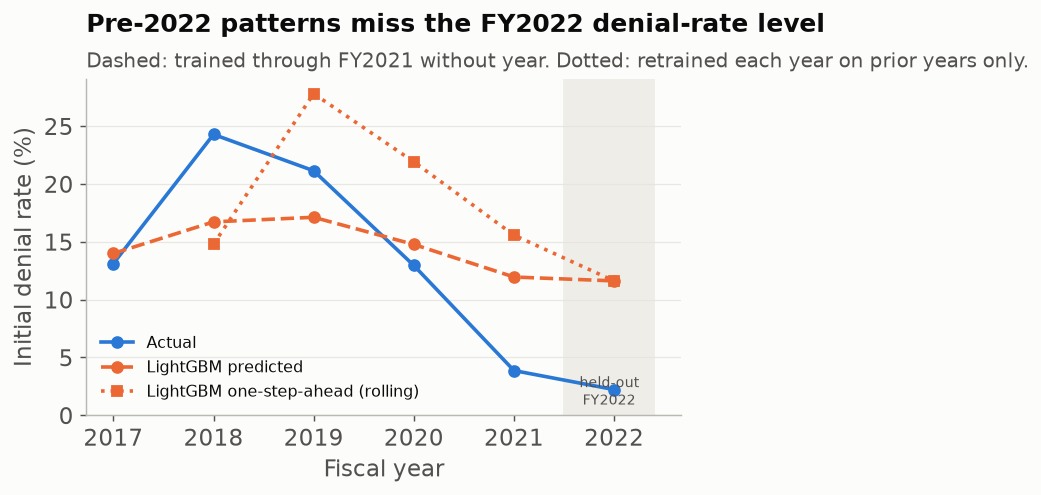

      actual  predicted
fy                     
2017   13.12      13.99
2018   24.28      16.72
2019   21.13      17.11
2020   12.95      14.76
2021    3.86      11.95
2022    2.21      11.61


In [9]:
pred_all_t = gbm_t.predict(Xg_t)
tmp = pd.DataFrame({"fy": fit_df.fy, "actual": y,
                    "pred": pred_all_t, "weight": weights})
byyr = tmp.groupby("fy").apply(
    lambda d: pd.Series({
        "actual": np.average(d.actual, weights=d.weight),
        "predicted": np.average(d.pred, weights=d.weight),
    }), include_groups=False) * 100

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(byyr.index, byyr.actual, color=C1, marker="o", markersize=6, label="Actual")
ax.plot(byyr.index, byyr.predicted, color=C2, marker="o", markersize=6,
        ls="--", label="LightGBM predicted")
ax.plot(roll.test_year, roll.gbm_pred_mean * 100, color=C2, marker="s",
        markersize=5, ls=":", label="LightGBM one-step-ahead (rolling)")
ax.axvspan(2021.5, 2022.4, color="#eeede8", zorder=0)
ax.text(2021.95, 0.5, "held-out\nFY2022", ha="center", va="bottom",
        fontsize=8, color=INK2)
ax.set_ylim(bottom=0)
ax.legend(loc="lower left", fontsize=9)
finish(ax, "Pre-2022 patterns miss the FY2022 denial-rate level",
       "Dashed: trained through FY2021 without year. Dotted: retrained each year on prior years only.",
       "Fiscal year", "Initial denial rate (%)")
save("09_temporal_failure")

byyr.round(3).to_csv(TABLES / "temporal_actual_vs_predicted.csv")
print(byyr.round(2).to_string())

## 5. What drives within-period predictions

WLS coefficients provide adjusted associations and clustered uncertainty. SHAP values
summarize the final LightGBM model on the untouched sponsor-disjoint test rows.

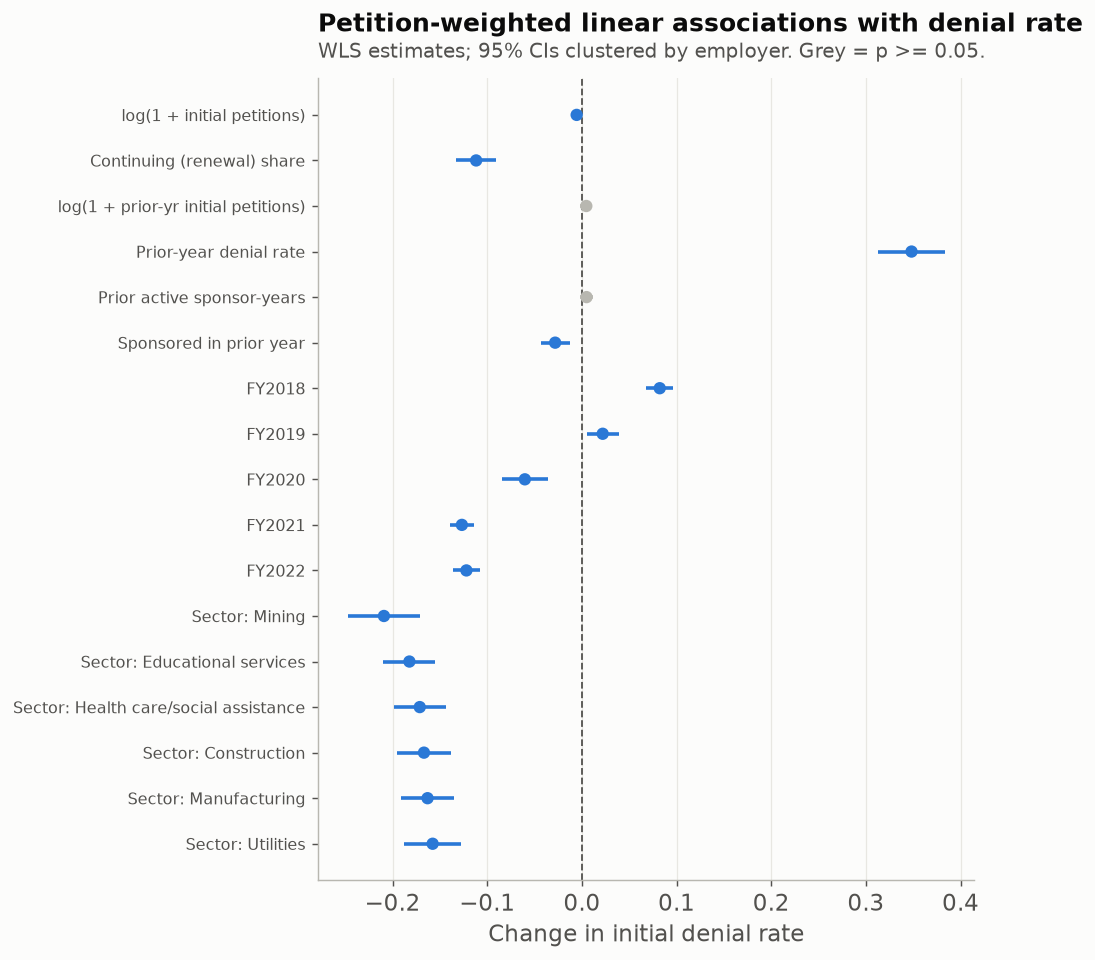

Selected WLS coefficients:
  log(1 + initial petitions)               -0.0055   p=0.00192
  Continuing (renewal) share               -0.1117   p=1.51e-24
  log(1 + prior-yr initial petitions)       0.0046   p=0.162
  Prior-year denial rate                    0.3482   p=6.25e-85
  Prior active sponsor-years                0.0049   p=0.188
  Sponsored in prior year                  -0.0283   p=0.000334


In [10]:
res = pd.DataFrame({"coef": wls.params, "lo": wls.conf_int()[0],
                    "hi": wls.conf_int()[1], "p": wls.pvalues}).drop("const")
res.to_csv(TABLES / "wls_coefficients.csv")

sector_rows = res[res.index.str.startswith("sector_")]
top_sectors = sector_rows.reindex(
    sector_rows.coef.abs().sort_values(ascending=False).index[:6])
show = pd.concat([res.loc[[c for c in res.index if c in PRETTY]],
                  res[res.index.str.startswith("fy_cat_")], top_sectors])
labels = [PRETTY.get(i, i.replace("fy_cat_", "FY").replace("sector_", "Sector: "))
          for i in show.index]

forest_plot(show, labels,
            "Petition-weighted linear associations with denial rate",
            "WLS estimates; 95% CIs clustered by employer. Grey = p >= 0.05.",
            "Change in initial denial rate", "06_forest_plot_ols")

print("Selected WLS coefficients:")
for k in NUMERIC:
    print(f"  {PRETTY[k]:40s} {wls.params[k]: .4f}   p={wls.pvalues[k]:.3g}")

SHAP computed on a random sample of 4,000 of 49,697 sponsor-disjoint test rows (seed 45)


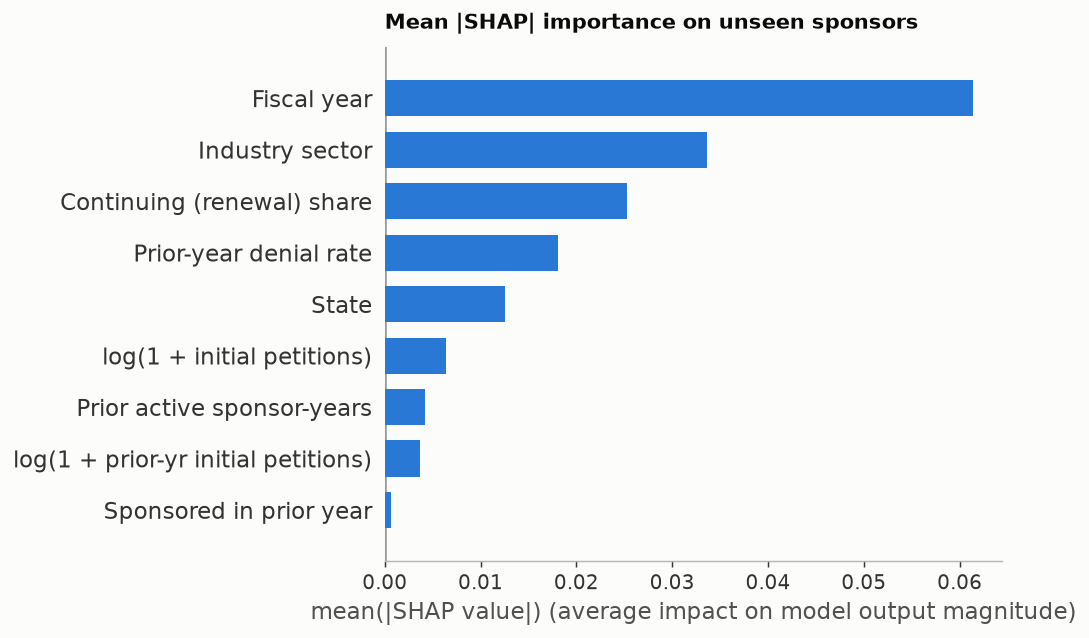

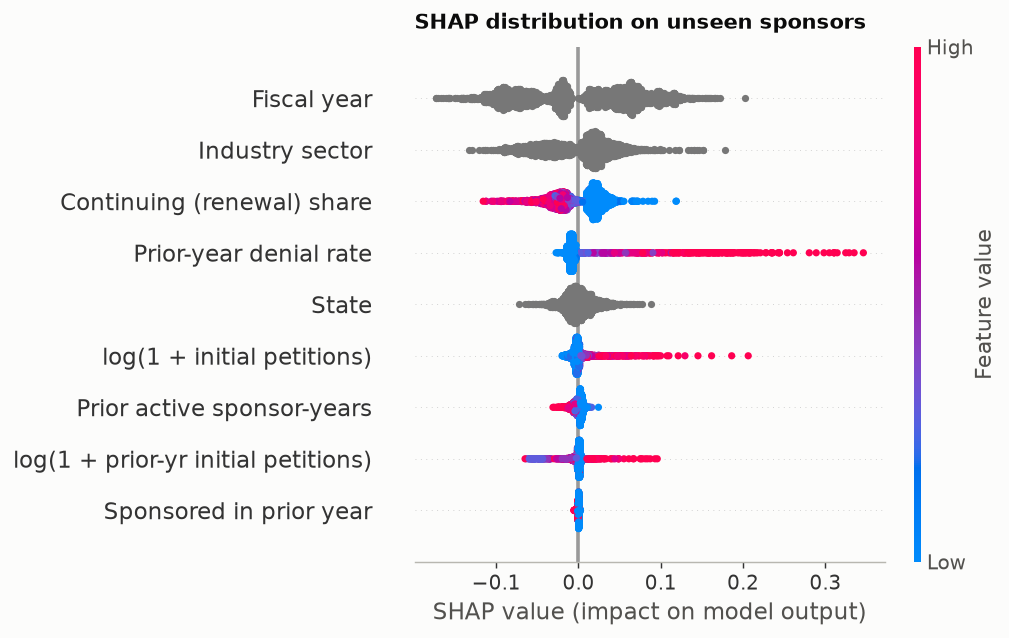

Fiscal year                            0.06138
Industry sector                        0.03363
Continuing (renewal) share             0.02529
Prior-year denial rate                 0.01811
State                                  0.01257
log(1 + initial petitions)             0.00639
Prior active sponsor-years             0.00424
log(1 + prior-yr initial petitions)    0.00370
Sponsored in prior year                0.00063


In [11]:
sample_n = min(4000, len(te))
samp_idx = pd.Series(te).sample(sample_n, random_state=SEED).to_numpy()
print(f"SHAP computed on a random sample of {sample_n:,} of {len(te):,} "
      f"sponsor-disjoint test rows (seed {SEED})")
samp = X_gbm.iloc[samp_idx]
explainer = shap.TreeExplainer(gbm)
sv = explainer.shap_values(samp)
samp_named = samp.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 4.6))
shap.summary_plot(sv, samp_named, plot_type="bar", show=False,
                  color=SEQ, max_display=12)
plt.title("Mean |SHAP| importance on unseen sponsors", loc="left",
          fontsize=11.5, color=INK)
save("07_shap_bar")

# SHAP uses random vertical jitter in beeswarm plots; seed it for byte-stable reruns.
np.random.seed(SEED)
plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv, samp_named, show=False, max_display=12)
plt.title("SHAP distribution on unseen sponsors", loc="left",
          fontsize=11.5, color=INK)
save("08_shap_beeswarm")

std_beta = (wls.params.drop("const") * X_lin.iloc[dev].std()) / y[dev].std()
lin_imp = std_beta.abs().sort_values(ascending=False).head(12)
gbm_imp = pd.Series(np.abs(sv).mean(0), index=samp_named.columns).sort_values(ascending=False)
lin_imp.to_csv(TABLES / "linear_importance.csv")
gbm_imp.to_csv(TABLES / "shap_importance.csv")
print(gbm_imp.round(5).to_string())

## 6. Does the wage block add predictive information?

Baseline and wage specifications use the same exact-match rows and the same sponsor-
disjoint partitions. Wage medians used for imputation are learned from the training rows of each partition, inside the fit.
This comparison isolates features from sample selection, although it cannot eliminate
selection into the matched sample itself.

In [12]:
fitw = panel[panel.lca_filings.notna() & panel.fy.isin(MODEL_YEARS)].copy()
fitw = fitw.reset_index(drop=True)
fitw["fy_cat"] = fitw.fy.astype(str)
fitw["log_wage_annual"] = np.log(fitw.wage_annual_med)
fitw["log_lca_filings"] = np.log1p(fitw.lca_filings)
fitw["soc2_modal"] = fitw.soc2_modal.fillna("UNKNOWN").astype(str)

trw, vaw, tew = group_partitions(fitw)
devw = np.sort(np.concatenate([trw, vaw]))
# Wage medians for imputation are computed inside fit_pair from the training rows
# of whichever partition is being fitted, so each seed uses its own medians.
print("missing wage features before imputation:")
print(fitw[WAGE_NUM].isna().mean().round(4).to_string())

split_wage = split_diagnostic(fitw, trw, vaw, tew, "matched employer-years")
pd.concat([split_base, split_wage], ignore_index=True).to_csv(
    TABLES / "split_diagnostics.csv", index=False)

yw = fitw.denial_rate.to_numpy()
ywb = fitw.any_denial.to_numpy()
ww = fitw.initial_total.to_numpy(dtype=float)
gw = fitw.key.to_numpy()
print(f"\nmatched rows: {len(fitw):,} "
      f"({len(fitw) / len(fit_df):.1%} of model-window employer-years)")
print(f"test set (matched employer-years): {len(tew):,} rows, "
      f"{fitw.iloc[tew].key.nunique():,} employers")

missing wage features before imputation:
wage_ratio_med     0.0021
log_wage_annual    0.0021
share_low_level    0.0186
share_agent        0.0034
share_dependent    0.0000
log_lca_filings    0.0000
matched employer-years
  train      rows=66,725 employers=34,805
  validation rows=16,719 employers=8,702


  test       rows=35,741 employers=18,646
  employer overlap across partitions: 0

matched rows: 119,185 (72.0% of model-window employer-years)
test set (matched employer-years): 35,741 rows, 18,646 employers


In [13]:
base = fit_pair(fitw, yw, ywb, ww, gw, trw, vaw, tew, devw,
                NUMERIC, CATEG, "Baseline (no wages)")
full = fit_pair(fitw, yw, ywb, ww, gw, trw, vaw, tew, devw,
                NUMERIC + WAGE_NUM, CATEG + WAGE_CAT, "With wage features")
comp2 = pd.DataFrame(
    [{"Model": "WLS / Logistic", "Features": m["label"],
      "Petition-weighted R2": round(m["r2_wls"], 4),
      "AUC": round(m["auc_logit"], 4)} for m in (base, full)] +
    [{"Model": "LightGBM", "Features": m["label"],
      "Petition-weighted R2": round(m["r2_gbm"], 4),
      "AUC": round(m["auc_gbm"], 4)} for m in (base, full)])
comp2.to_csv(TABLES / "model_comparison_wages.csv", index=False)
print("\n" + comp2.to_string(index=False))

Baseline (no wages)    WLS R2=0.3530; LGBM R2=0.4771; Logit AUC=0.8260; LGBM AUC=0.8356; frac-logit R2=0.4256


With wage features     WLS R2=0.3821; LGBM R2=0.5283; Logit AUC=0.8420; LGBM AUC=0.8537; frac-logit R2=0.4843

         Model            Features  Petition-weighted R2    AUC
WLS / Logistic Baseline (no wages)                0.3530 0.8260
WLS / Logistic  With wage features                0.3821 0.8420
      LightGBM Baseline (no wages)                0.4771 0.8356
      LightGBM  With wage features                0.5283 0.8537


### Wage coefficients and tree importance

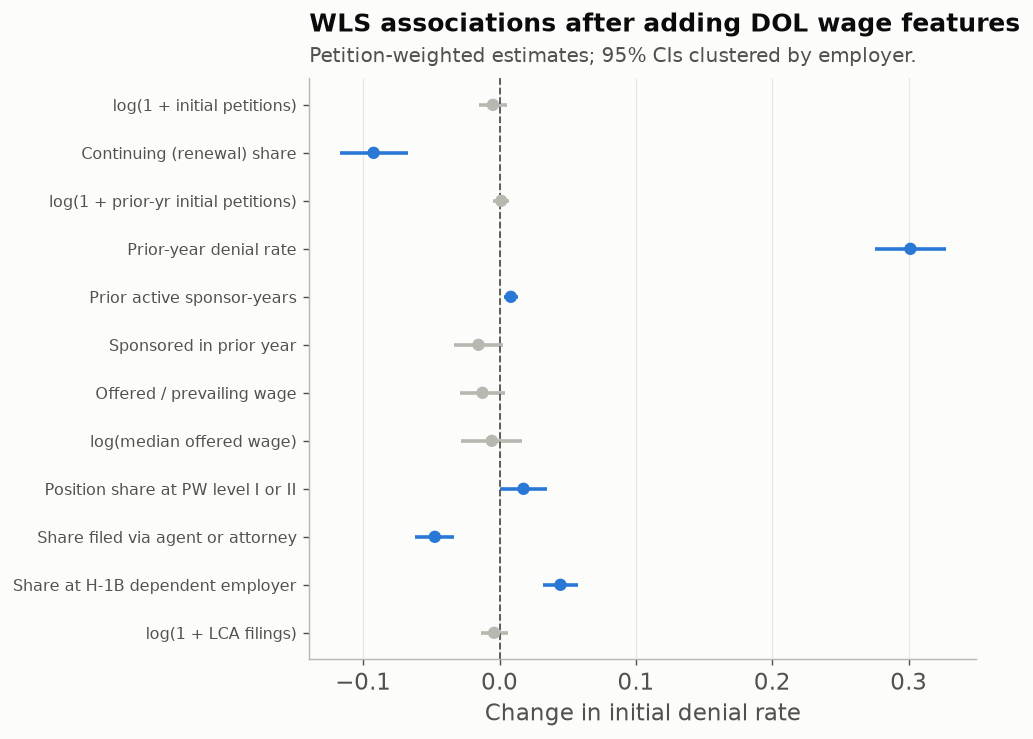

Wage-feature coefficients:
  Offered / prevailing wage                -0.0125   p=0.141
  log(median offered wage)                 -0.0056   p=0.621
  Position share at PW level I or II        0.0176   p=0.0444
  Share filed via agent or attorney        -0.0474   p=1.01e-10
  Share at H-1B dependent employer          0.0447   p=5.87e-12
  log(1 + LCA filings)                     -0.0040   p=0.434


In [14]:
model_w = full["wls"]
res_w = pd.DataFrame({"coef": model_w.params, "lo": model_w.conf_int()[0],
                      "hi": model_w.conf_int()[1], "p": model_w.pvalues}).drop("const")
res_w.to_csv(TABLES / "wls_coefficients_wages.csv")
order = [c for c in PRETTY if c in res_w.index]
show_w = res_w.loc[order]

forest_plot(show_w, [PRETTY[i] for i in show_w.index],
            "WLS associations after adding DOL wage features",
            "Petition-weighted estimates; 95% CIs clustered by employer.",
            "Change in initial denial rate", "13_forest_plot_wages")

print("Wage-feature coefficients:")
for k in WAGE_NUM:
    print(f"  {PRETTY[k]:40s} {model_w.params[k]: .4f}   p={model_w.pvalues[k]:.3g}")

SHAP computed on a random sample of 4,000 of 35,741 matched sponsor-disjoint test rows (seed 45)


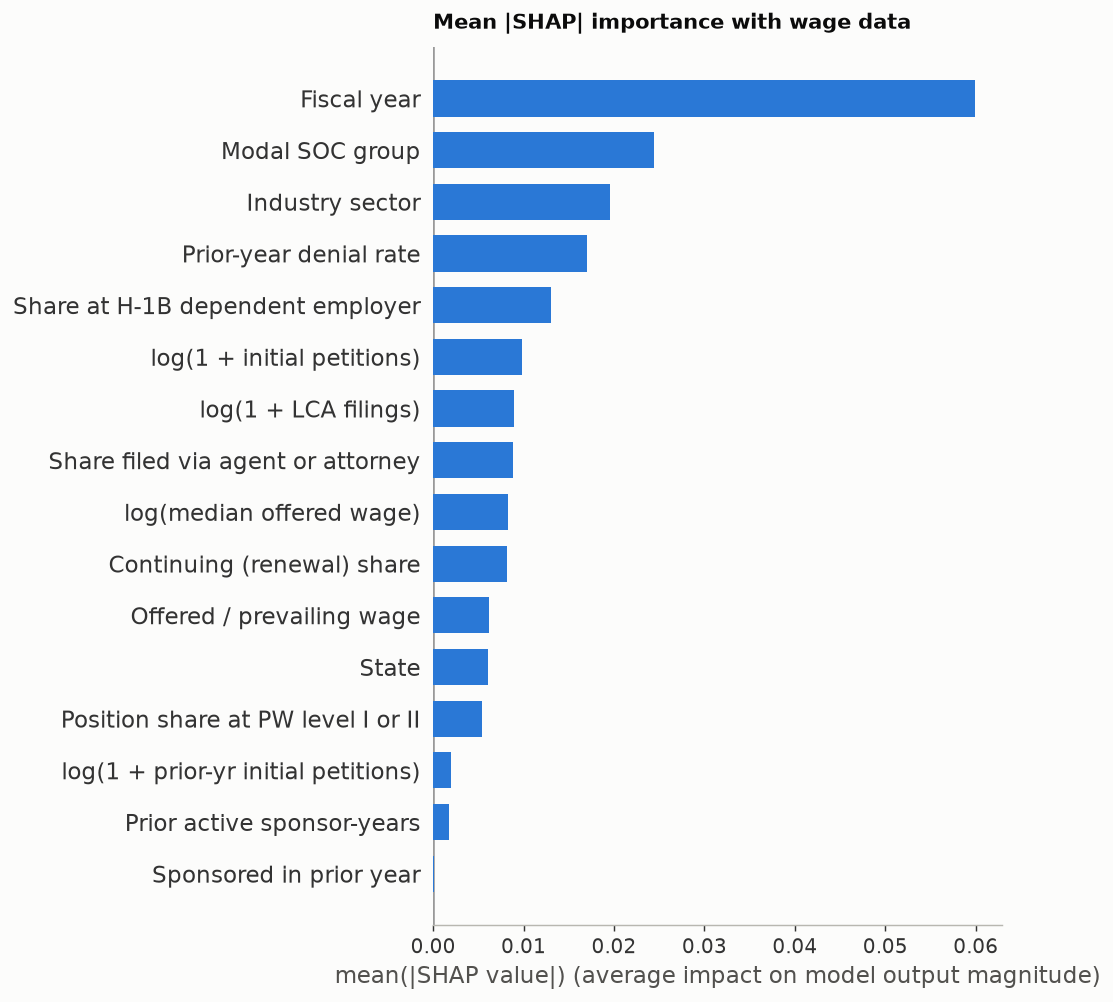

Fiscal year                            0.05994
Modal SOC group                        0.02440
Industry sector                        0.01955
Prior-year denial rate                 0.01705
Share at H-1B dependent employer       0.01304
log(1 + initial petitions)             0.00985
log(1 + LCA filings)                   0.00894
Share filed via agent or attorney      0.00885
log(median offered wage)               0.00829
Continuing (renewal) share             0.00822
Offered / prevailing wage              0.00614
State                                  0.00606
Position share at PW level I or II     0.00541
log(1 + prior-yr initial petitions)    0.00201
Prior active sponsor-years             0.00176
Sponsored in prior year                0.00012


In [15]:
sample_n_w = min(4000, len(tew))
samp_idx_w = pd.Series(tew).sample(sample_n_w, random_state=SEED).to_numpy()
print(f"SHAP computed on a random sample of {sample_n_w:,} of {len(tew):,} "
      f"matched sponsor-disjoint test rows (seed {SEED})")
samp_w = full["X_gbm"].iloc[samp_idx_w]
explainer_w = shap.TreeExplainer(full["gbm"])
sv_w = explainer_w.shap_values(samp_w)
samp_w_named = samp_w.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv_w, samp_w_named, plot_type="bar", show=False,
                  color=SEQ, max_display=16)
plt.title("Mean |SHAP| importance with wage data", loc="left",
          fontsize=11.5, color=INK)
save("14_shap_bar_wages")

gbm_imp_w = pd.Series(
    np.abs(sv_w).mean(0), index=samp_w_named.columns).sort_values(ascending=False)
gbm_imp_w.to_csv(TABLES / "shap_importance_wages.csv")
print(gbm_imp_w.round(5).to_string())

## 7. Repeated sponsor-disjoint splits

A single split gives one point estimate per model. To see whether the gaps in Tables 1
and 2 exceed split-to-split noise, the whole pipeline (split, tune on validation, refit on
development rows, score on test) is repeated over ten seeds. Seed 45 remains the headline
split reported above.

In [16]:
SEEDS = range(45, 55)
print("all employer-years")
seed_all = seed_metrics(fit_df, y, y_bin, weights, groups, NUMERIC, CATEG,
                        "All employer-years", SEEDS)
print("matched employer-years")
seed_base = seed_metrics(fitw, yw, ywb, ww, gw, NUMERIC, CATEG,
                         "Matched, baseline", SEEDS)
seed_wage = seed_metrics(fitw, yw, ywb, ww, gw, NUMERIC + WAGE_NUM,
                         CATEG + WAGE_CAT, "Matched, with wages", SEEDS)

seed_all_runs = pd.concat([seed_all, seed_base, seed_wage], ignore_index=True)
print(f"concat seed runs: {len(seed_all)}+{len(seed_base)}+{len(seed_wage)} "
      f"-> {len(seed_all_runs)}")
assert len(seed_all_runs) == 3 * len(SEEDS)
metrics = ["r2_wls", "r2_gbm", "auc_logit", "auc_gbm", "r2_frac"]
seed_summary = (seed_all_runs.groupby("sample", sort=False)[metrics]
                .agg(["mean", "std"]))
seed_summary.columns = [f"{a}_{b}" for a, b in seed_summary.columns]
seed_summary["n_seeds"] = len(SEEDS)
seed_summary.to_csv(TABLES / "model_metrics_seeds.csv")
seed_all_runs.to_csv(TABLES / "model_metrics_seeds_runs.csv", index=False)
print("\n" + seed_summary.round(4).to_string())

# Paired differences within each seed, so the gap is measured on the same split.
gap = pd.DataFrame({
    "LGBM - WLS R2 (all)": seed_all.r2_gbm - seed_all.r2_wls,
    "LGBM - logit AUC (all)": seed_all.auc_gbm - seed_all.auc_logit,
    "wages - baseline, WLS R2": seed_wage.r2_wls.to_numpy() - seed_base.r2_wls.to_numpy(),
    "wages - baseline, LGBM R2": seed_wage.r2_gbm.to_numpy() - seed_base.r2_gbm.to_numpy(),
    "wages - baseline, logit AUC": seed_wage.auc_logit.to_numpy() - seed_base.auc_logit.to_numpy(),
    "wages - baseline, LGBM AUC": seed_wage.auc_gbm.to_numpy() - seed_base.auc_gbm.to_numpy(),
    "frac logit - WLS R2 (all)": seed_all.r2_frac - seed_all.r2_wls,
    "frac logit - WLS R2 (matched, wages)": seed_wage.r2_frac.to_numpy() - seed_wage.r2_wls.to_numpy(),
})
gap_summary = pd.DataFrame({"mean": gap.mean(), "sd": gap.std(),
                            "min": gap.min(), "max": gap.max()})
gap_summary.to_csv(TABLES / "model_metrics_seed_gaps.csv")
print("\npaired gaps across seeds:")
print(gap_summary.round(4).to_string())


all employer-years


  All employer-years     seed=45  WLS R2=0.2957  LGBM R2=0.4187  Logit AUC=0.7884  LGBM AUC=0.7973  frac R2=0.3408


  All employer-years     seed=46  WLS R2=0.2856  LGBM R2=0.3944  Logit AUC=0.7928  LGBM AUC=0.8006  frac R2=0.3417


  All employer-years     seed=47  WLS R2=0.3330  LGBM R2=0.4393  Logit AUC=0.7902  LGBM AUC=0.7991  frac R2=0.3860


  All employer-years     seed=48  WLS R2=0.2849  LGBM R2=0.3938  Logit AUC=0.7875  LGBM AUC=0.7978  frac R2=0.3323


...

  Matched, with wages    seed=50  WLS R2=0.3468  LGBM R2=0.4962  Logit AUC=0.8466  LGBM AUC=0.8566  frac R2=0.4576


  Matched, with wages    seed=51  WLS R2=0.3643  LGBM R2=0.5024  Logit AUC=0.8464  LGBM AUC=0.8546  frac R2=0.4538


  Matched, with wages    seed=52  WLS R2=0.3966  LGBM R2=0.5459  Logit AUC=0.8483  LGBM AUC=0.8591  frac R2=0.5114


  Matched, with wages    seed=53  WLS R2=0.3520  LGBM R2=0.4890  Logit AUC=0.8402  LGBM AUC=0.8521  frac R2=0.4324


  Matched, with wages    seed=54  WLS R2=0.4021  LGBM R2=0.5441  Logit AUC=0.8469  LGBM AUC=0.8558  frac R2=0.5039
concat seed runs: 10+10+10 -> 30

                     r2_wls_mean  r2_wls_std  r2_gbm_mean  r2_gbm_std  auc_logit_mean  auc_logit_std  auc_gbm_mean  auc_gbm_std  r2_frac_mean  r2_frac_std  n_seeds
sample                                                                                                                                                             
All employer-years        0.3031      0.0231       0.4140      0.0223          0.7895         0.0022        0.7984       0.0019        0.3563       0.0245       10
Matched, baseline         0.3346      0.0304       0.4583      0.0280          0.8281         0.0025        0.8369       0.0021        0.4026       0.0329       10
Matched, with wages       0.3635      0.0280       0.5122      0.0249          0.8443         0.0027        0.8548       0.0020        0.4627       0.0322       10

paired gaps across seeds:
    

## 8. Robustness: lagged-only features and a fractional logit

Two of the history measures, `log_initial` and `continuing_share`, describe the same
fiscal year as the outcome. The first row block below drops them and uses only quantities
known before the year starts: prior-year initial petitions, prior-year continuing share,
prior-year denial rate, prior active years, and the repeat-sponsor flag.

The second block replaces the unclipped WLS with a fractional logit (GLM Binomial on the
rate with petition weights and employer-clustered standard errors), on the main sample
and on the matched sample with wage features. All rows use the seed-45 partitions; the ten-seed mean of the fractional logit is in `model_metrics_seeds.csv`.

In [17]:
# Prior-year continuing share from the sponsor's own row one fiscal year earlier.
prev_share = panel[["key", "fy", "continuing_total", "petitions_total"]].copy()
prev_share["prev_continuing_share"] = (
    prev_share.continuing_total / prev_share.petitions_total.replace(0, np.nan)).fillna(0)
prev_share["fy"] = prev_share.fy + 1
prev_share = prev_share[["key", "fy", "prev_continuing_share"]]
describe_frame(fit_df, "BEFORE merge (lag): model panel", keys=["key", "fy"])
describe_frame(prev_share, "BEFORE merge (lag): prior-year continuing share",
               keys=["key", "fy"])
before_rows = len(fit_df)
fit_df = fit_df.merge(prev_share, on=["key", "fy"], how="left", validate="one_to_one")
describe_frame(fit_df, "AFTER merge (lag)", keys=["key", "fy"])
assert len(fit_df) == before_rows
merge_report(fit_df, "prev_continuing_share", weight_col="initial_total")
fit_df["prev_continuing_share"] = fit_df.prev_continuing_share.fillna(0)
print(f"prior-year continuing share available for "
      f"{(fit_df.is_repeat_sponsor == 1).mean():.1%} of rows (others set to 0)")

NUMERIC_LAG = ["log_prev_initial", "prev_continuing_share", "prev_denial_rate",
               "prior_active_years", "is_repeat_sponsor"]
PRETTY["prev_continuing_share"] = "Prior-year continuing share"

main_m = fit_pair(fit_df, y, y_bin, weights, groups, tr, va, te, dev,
                  NUMERIC, CATEG, "Main spec")
lag_m = fit_pair(fit_df, y, y_bin, weights, groups, tr, va, te, dev,
                 NUMERIC_LAG, CATEG, "Lagged-only spec")

# Fractional logit rows.
frac = fit_fraclogit(X_lin, y, weights, groups, dev)
frac_pred = predict_glm(frac, X_lin, te)
r2_frac = r2_score(y[te], frac_pred, sample_weight=weights[te])
frac_w = fit_fraclogit(full["X_lin"], yw, ww, gw, devw)
frac_w_pred = predict_glm(frac_w, full["X_lin"], tew)
r2_frac_w = r2_score(yw[tew], frac_w_pred, sample_weight=ww[tew])
print(f"fractional logit held-out R2: main sample={r2_frac:.4f}; "
      f"matched with wages={r2_frac_w:.4f}")
print(f"WLS predictions outside [0,1] on test: "
      f"{((wls_pred < 0) | (wls_pred > 1)).mean():.1%}")

robust = pd.DataFrame([
    {"sample": "All employer-years", "spec": "Main (WLS)", "metric": "Petition-weighted R2", "score": main_m["r2_wls"]},
    {"sample": "All employer-years", "spec": "Main (LightGBM)", "metric": "Petition-weighted R2", "score": main_m["r2_gbm"]},
    {"sample": "All employer-years", "spec": "Main (logistic)", "metric": "ROC AUC", "score": main_m["auc_logit"]},
    {"sample": "All employer-years", "spec": "Main (LightGBM classifier)", "metric": "ROC AUC", "score": main_m["auc_gbm"]},
    {"sample": "All employer-years", "spec": "Lagged-only (WLS)", "metric": "Petition-weighted R2", "score": lag_m["r2_wls"]},
    {"sample": "All employer-years", "spec": "Lagged-only (LightGBM)", "metric": "Petition-weighted R2", "score": lag_m["r2_gbm"]},
    {"sample": "All employer-years", "spec": "Lagged-only (logistic)", "metric": "ROC AUC", "score": lag_m["auc_logit"]},
    {"sample": "All employer-years", "spec": "Lagged-only (LightGBM classifier)", "metric": "ROC AUC", "score": lag_m["auc_gbm"]},
    {"sample": "All employer-years", "spec": "Fractional logit, main features", "metric": "Petition-weighted R2", "score": r2_frac},
    {"sample": "Matched employer-years", "spec": "WLS with wage features", "metric": "Petition-weighted R2", "score": full["r2_wls"]},
    {"sample": "Matched employer-years", "spec": "Fractional logit with wage features", "metric": "Petition-weighted R2", "score": r2_frac_w},
])
robust.to_csv(TABLES / "robustness.csv", index=False)
print("\n" + robust.round(4).to_string(index=False))

print("\nfractional logit coefficients (log-odds), main sample:")
for k in NUMERIC:
    print(f"  {PRETTY[k]:40s} {frac.params[k]: .4f}   p={frac.pvalues[k]:.3g}")
print("fractional logit wage coefficients (log-odds), matched sample:")
for k in WAGE_NUM:
    print(f"  {PRETTY[k]:40s} {frac_w.params[k]: .4f}   p={frac_w.pvalues[k]:.3g}")
print("\nlagged-only WLS coefficients:")
for k in NUMERIC_LAG:
    print(f"  {PRETTY[k]:40s} {lag_m['wls'].params[k]: .4f}   p={lag_m['wls'].pvalues[k]:.3g}")


--- BEFORE merge (lag): model panel ---
    rows: 165,593   columns: 39
    distinct key: 97,121
    distinct fy: 6
    columns with missing values: 13 (worst: soc2_modal at 35.3%)
--- BEFORE merge (lag): prior-year continuing share ---
    rows: 176,404   columns: 3
    distinct key: 100,152
    distinct fy: 7
    no missing values
--- AFTER merge (lag) ---
    rows: 165,593   columns: 40
    distinct key: 97,121
    distinct fy: 6


    columns with missing values: 14 (worst: prev_continuing_share at 67.3%)
    rows matched: 54,163 / 165,593  (32.7%)
    weighted by initial_total: 67.2%
prior-year continuing share available for 42.4% of rows (others set to 0)


Main spec              WLS R2=0.2957; LGBM R2=0.4187; Logit AUC=0.7884; LGBM AUC=0.7973; frac-logit R2=0.3408


Lagged-only spec       WLS R2=0.2892; LGBM R2=0.3643; Logit AUC=0.7487; LGBM AUC=0.7600; frac-logit R2=0.3294


fractional logit held-out R2: main sample=0.3408; matched with wages=0.4843
WLS predictions outside [0,1] on test: 10.9%

                sample                                spec               metric  score
    All employer-years                          Main (WLS) Petition-weighted R2 0.2957
    All employer-years                     Main (LightGBM) Petition-weighted R2 0.4187
    All employer-years                     Main (logistic)              ROC AUC 0.7884
    All employer-years          Main (LightGBM classifier)              ROC AUC 0.7973
    All employer-years                   Lagged-only (WLS) Petition-weighted R2 0.2892
    All employer-years              Lagged-only (LightGBM) Petition-weighted R2 0.3643
    All employer-years              Lagged-only (logistic)              ROC AUC 0.7487
    All employer-years   Lagged-only (LightGBM classifier)              ROC AUC 0.7600
    All employer-years     Fractional logit, main features Petition-weighted R2 0.3408
Matched 

## Interpretation

The executed tables provide three distinct estimates: generalization to unseen sponsors
within familiar fiscal years, transfer into a future policy year, and the incremental
value of wage data among exact agency matches. Keeping those estimands separate prevents
a strong within-period score from being mistaken for durable forward prediction.